In [120]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

In [139]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data["caffeine_class"]

column_names = X.columns

Binary classification - Model choice

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

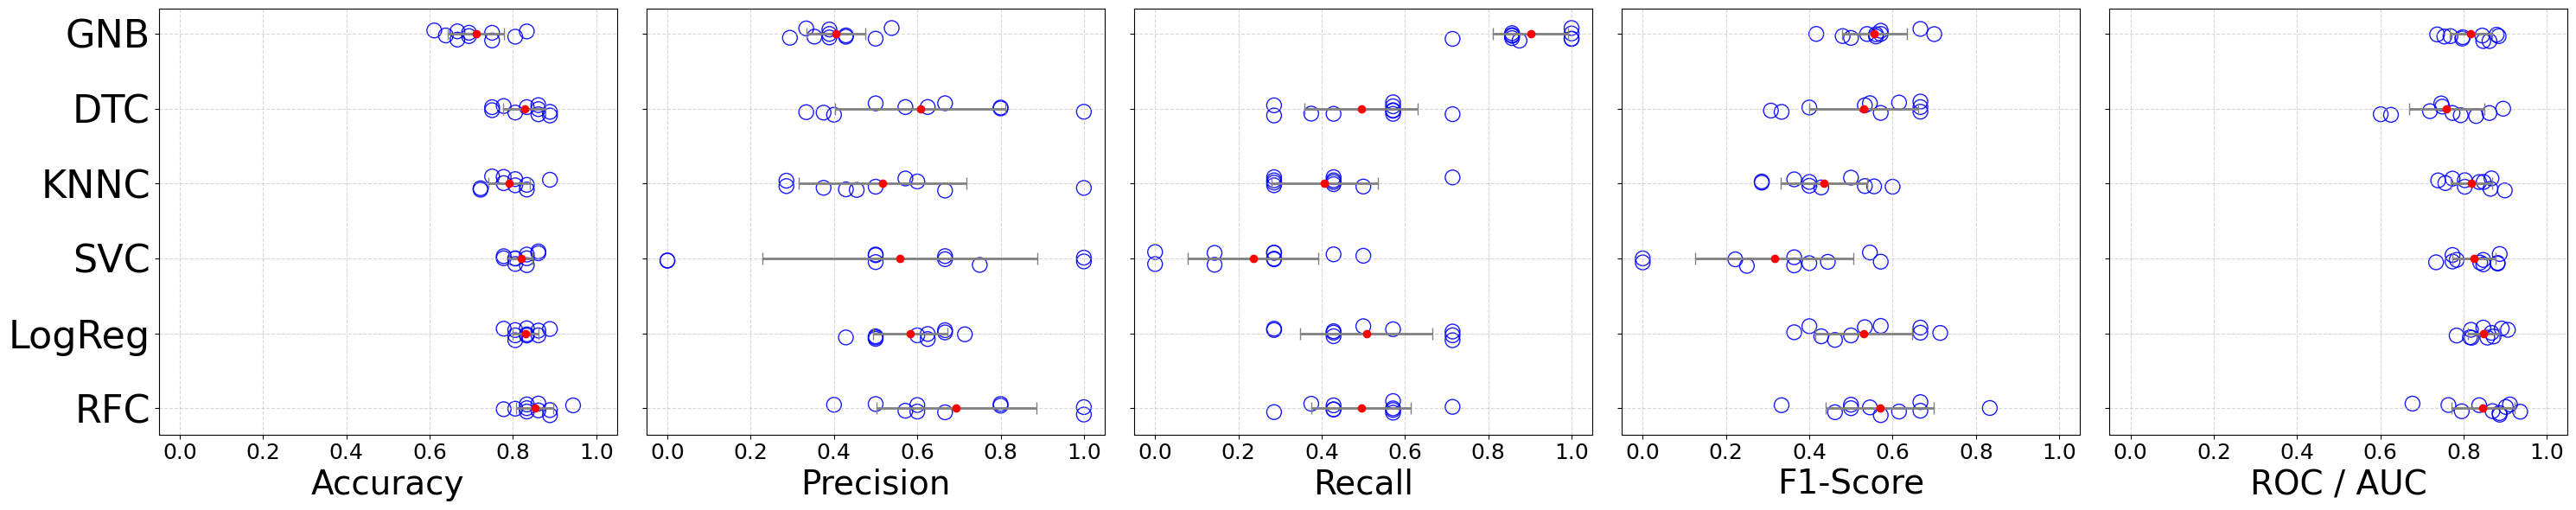

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


# ── 3) DEFINE MODELS ────────────────────────────────────────────────────────
models = [
    ("RFC", RandomForestClassifier(n_estimators=100, random_state=42)),
    (
        "LogReg",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
    ),
    (
        "SVC",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42)),
        ]),
    ),
    (
        "KNNC",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
    ),
    ("DTC", DecisionTreeClassifier(random_state=42)),
    ("GNB", GaussianNB()),
]

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_folds = 10
xlabel_map = {
    "accuracy":  "Accuracy",
    "precision":  "Precision",
    "recall": "Recall",
    "f1":   "F1-Score",
    "roc_auc":  "ROC / AUC"
}
# ── 4) CROSS-VALIDATION ──────────────────────────────────────────────────────
results = {m: [] for m in scoring_metrics}
all_scores = {m: [] for m in scoring_metrics}

for name, model in models:
    for metric in scoring_metrics:
        # Skip roc_auc if model has no probability or decision_function
        if metric == "roc_auc" and not (
            hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        ):
            continue

        scores = cross_val_score(
            model, X_train, y_train, cv=cv_folds, scoring=metric
        )
        results[metric].append({
            "Model": name,
            "Mean Score": scores.mean(),
            "Std Dev":   scores.std()
        })
        all_scores[metric] += [
            {"Model": name, "Score": s, "Metric": metric}
            for s in scores
        ]

# Convert into DataFrames
results_df    = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame(
    [entry for metric_list in all_scores.values() for entry in metric_list]
)

# ── 5) VISUALIZE WITH VERTICAL JITTER ────────────────────────────────────────
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(30, 6), sharey=True)

# Determine a common x-axis limit
global_scores = all_scores_df["Score"]
x_min, x_max = global_scores.min() - 0.05, global_scores.max() + 0.05

for ax, metric in zip(axes, scoring_metrics):
    df_res = results_df[metric]
    
    # Scatter each CV fold with a small jitter around the model's y-index
    for i, row in df_res.iterrows():
        model_name = row["Model"]
        scores     = all_scores_df.query(
            "Model == @model_name and Metric == @metric"
        )["Score"].values
        
        # Add vertical jitter in [-0.1, +0.1]
        y_jitter = i + np.random.uniform(-0.1, 0.1, size=scores.shape)
        
        ax.scatter(
            scores,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.9,
            s=150,
        )

    # Plot mean ± std exactly at y=i
    ax.errorbar(
        df_res["Mean Score"],
        range(len(df_res)),
        xerr=df_res["Std Dev"],
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=5,
    )

    ax.tick_params(axis='x', labelsize=18)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(range(len(df_res)))
    ax.set_yticklabels(df_res["Model"], fontsize=32)
    ax.set_xlabel(xlabel_map[metric], fontsize=28)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
